# Week 2

In [1]:
import pandas as pd
import jax.numpy as jnp

In [2]:
from src.utils import load_model
from drivers.utils import load_test_data, load_train_data

In [3]:
DATA_NAME = "b1"
TAG = "jans-split" 
MODEL = "ar_2_second_order_hmm"

In [4]:
model = load_model(model_name=MODEL, data_name=DATA_NAME, tag=TAG)

model

In [5]:
y_train, x_train = load_train_data(DATA_NAME, TAG)
y_test, x_test = load_test_data(DATA_NAME, TAG)

In [6]:
y_train.shape

(1666,)

In [7]:
#Training loop

steps = 6
NO_OF_OBS = 100

ys = y_train.copy()
y_test = y_test[:NO_OF_OBS]
prediction_matrix = model.predict_emission(n_steps=steps, ys=ys)
ys = jnp.append(ys, y_test[0])

for i in range(1, len(y_test) - steps):
    pred = model.predict_emission(n_steps=steps, ys=ys) 
    ys = jnp.append(ys, y_test[i]) 
    prediction_matrix = jnp.vstack([prediction_matrix, pred])

    if (i % 10 == 0):
        print(f"Processed {i} out of {len(y_test) - steps} test observations.")


Processed 10 out of 94 test observations.
Processed 20 out of 94 test observations.
Processed 30 out of 94 test observations.
Processed 40 out of 94 test observations.
Processed 50 out of 94 test observations.
Processed 60 out of 94 test observations.
Processed 70 out of 94 test observations.
Processed 80 out of 94 test observations.
Processed 90 out of 94 test observations.


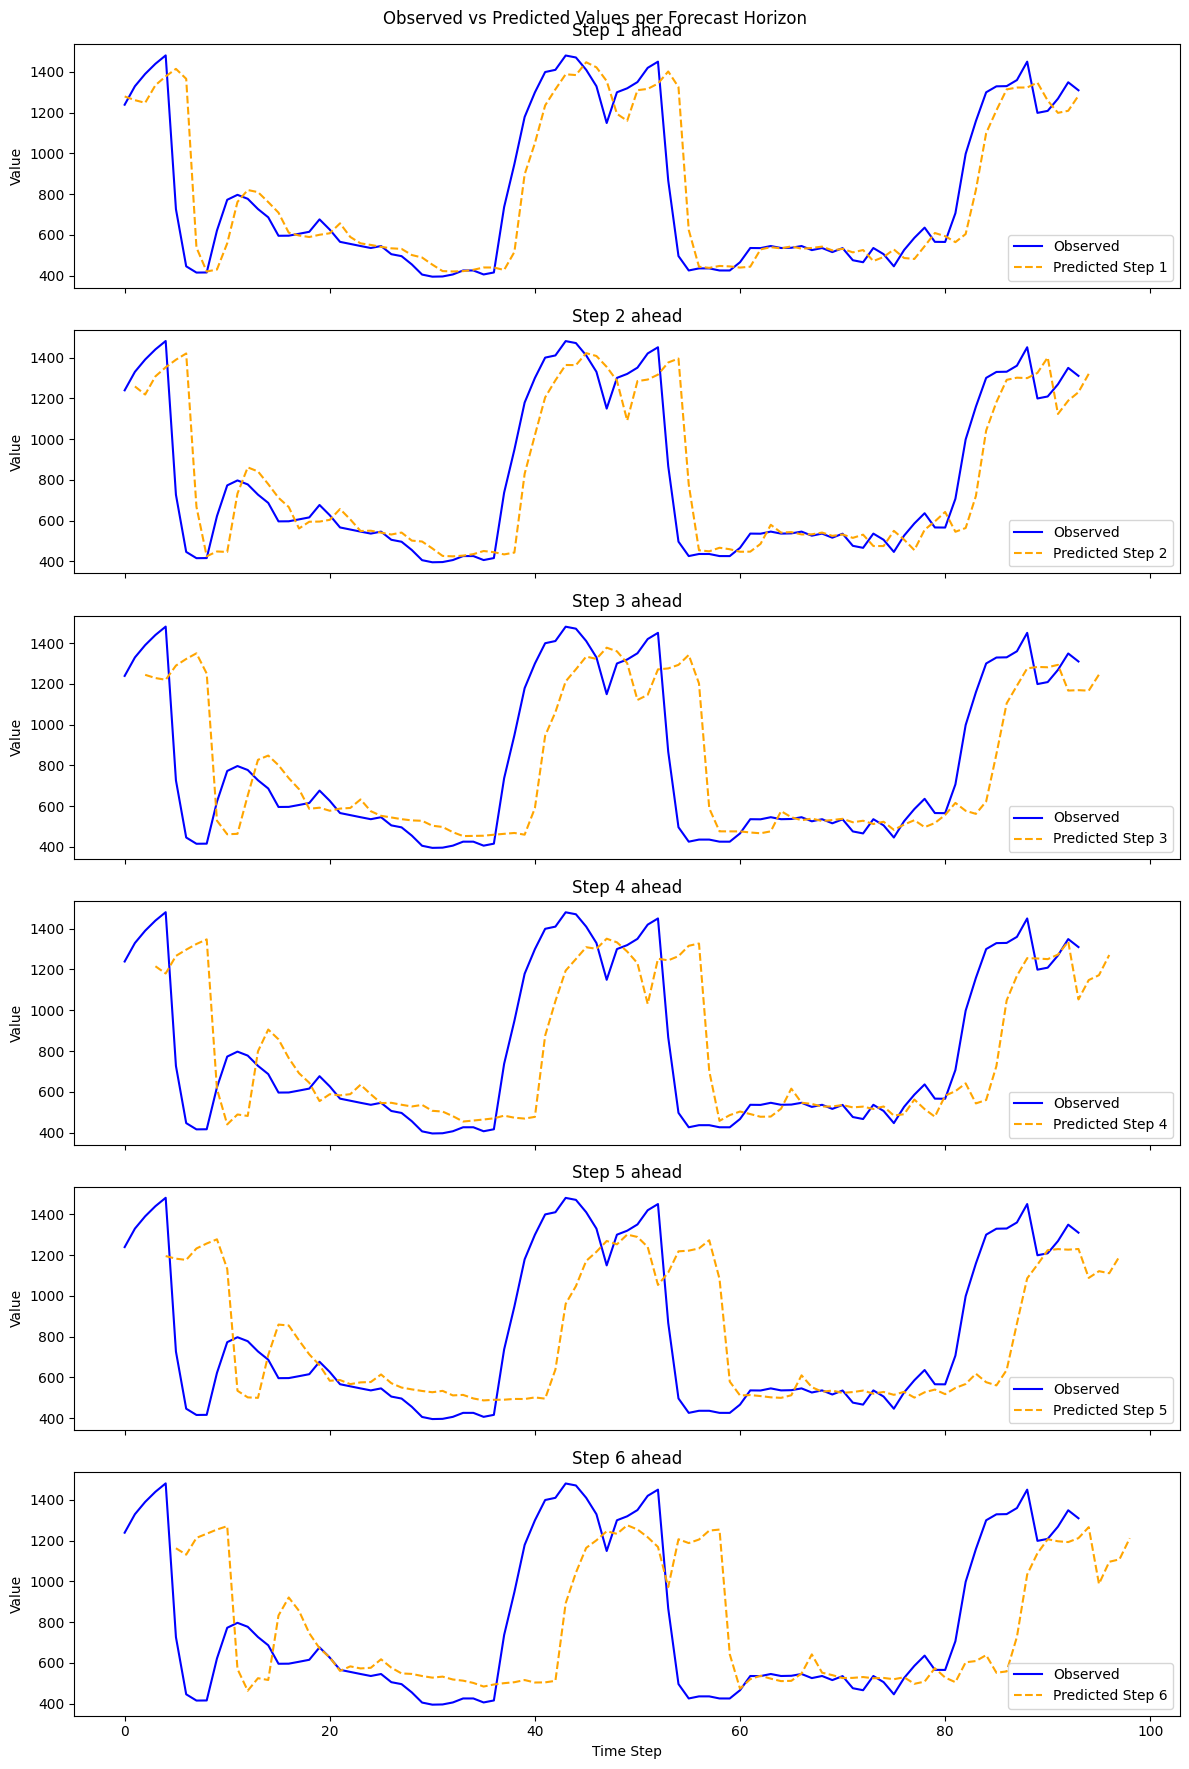

In [8]:
import numpy as np
import matplotlib.pyplot as plt

y_obs = y_test[:prediction_matrix.shape[0]].copy()
n_rows = prediction_matrix.shape[0]

fig, axes = plt.subplots(steps, 1, figsize=(12, 3 * steps), sharex=True)

for step, ax in enumerate(axes.ravel()):
    # Full observed series in every panel.
    ax.plot(y_obs, label='Observed', color='blue')
    # Align this horizon's predictions to the time they forecast: y_test[r + step].
    x = np.arange(n_rows) + step
    ax.plot(x, prediction_matrix[:, step], label=f'Predicted Step {step + 1}',
            linestyle='--', color='orange')
    ax.set_title(f'Step {step + 1} ahead')
    ax.set_ylabel('Value')
    ax.legend()

axes[-1].set_xlabel('Time Step')
fig.suptitle('Observed vs Predicted Values per Forecast Horizon')
fig.tight_layout()
plt.show()

In [9]:
def r2(y_true, y_pred):
    ss_res = jnp.sum((y_true - y_pred) ** 2)
    ss_tot = jnp.sum((y_true - jnp.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot) 


def rmse(y_true, y_pred):
    return jnp.sqrt(jnp.mean((y_true - y_pred) ** 2)) 

def mape(y_true, y_pred):
    return jnp.mean(jnp.abs((y_true - y_pred) / y_true)) * 100 


n_rows = prediction_matrix.shape[0]

# Persistence baseline: each row r forecasts from the last TRUE value known at its
# origin (y_train[-1] for r=0, else y_test[r-1]). The naive h-step forecast just
# repeats that origin value for every horizon.
anchor = jnp.append(y_train[-1], y_test)[:n_rows]

for step in range(steps):
    # Column `step` holds the (step+1)-step-ahead forecast, so it predicts
    # y_test[r + step] for row r. Shift the actuals to match the horizon.
    y_true = y_test[step : step + n_rows]
    y_model = prediction_matrix[:, step]
    y_naive = anchor  # persistence forecast

    print(
        f"Step {step + 1}: "
        f"model  R^2={r2(y_true, y_model):.4f} RMSE={rmse(y_true, y_model):.4f} MAPE={mape(y_true, y_model):.4f}%  |  "
        f"naive  R^2={r2(y_true, y_naive):.4f} RMSE={rmse(y_true, y_naive):.4f} MAPE={mape(y_true, y_naive):.4f}%"
    )

Step 1: model  R^2=0.7409 RMSE=195.3790 MAPE=15.1449%  |  naive  R^2=0.8685 RMSE=139.1890 MAPE=9.9995%
Step 2: model  R^2=0.6843 RMSE=216.3474 MAPE=17.8778%  |  naive  R^2=0.6355 RMSE=232.4747 MAPE=18.9222%
Step 3: model  R^2=0.3615 RMSE=308.2774 MAPE=28.2848%  |  naive  R^2=0.3876 RMSE=301.8936 MAPE=26.3022%
Step 4: model  R^2=0.2835 RMSE=323.8142 MAPE=29.7077%  |  naive  R^2=0.1380 RMSE=355.1597 MAPE=33.0727%
Step 5: model  R^2=0.0637 RMSE=364.8379 MAPE=35.0699%  |  naive  R^2=-0.1006 RMSE=395.5556 MAPE=38.2851%
Step 6: model  R^2=-0.0161 RMSE=373.3271 MAPE=35.9477%  |  naive  R^2=-0.3304 RMSE=427.1954 MAPE=42.0806%
